# Overall Results

Set `JOB_FOLDER` in the cell below to a completed job directory. The cell reads `results/_stats_cache.json` and `results/fitness_history.csv`, then plots global fitness history and the per-Sunday delta distribution against the random solution.


Loaded stats from: C:\Users\stjep\Downloads\DemoFitness\results\_stats_cache.json
Cache metadata:
{'random_name': 'random_start.json', 'optimized_name': 'solution.json', 'rand_mtime': 1782466678.55433, 'opt_mtime': 1782466809.6140869, 'created_at': '2026-06-26T09:40:09.816770+00:00'}
Overall stats:
{'random': 86.61346575385899, 'optimized': 102.13452449186197, 'delta': 15.521058738002978}
Execution timing:


,metric,started_at,finished_at,duration_seconds,source,reliability
0,backend run,2026-06-26 11:37:57.971158+02:00,2026-06-26 11:40:09.817866+02:00,131.846708,descriptor.job run_info,persisted for new runs
1,java process,2026-06-26 11:37:57.972087+02:00,2026-06-26 11:40:09.664853+02:00,131.692766,descriptor.job run_info,persisted for new runs


,sunday,random,optimized,delta,delta_pct,sunday_label
0,0,119.236744,105.426792,-13.809952,-11.581960,1
1,1,122.353407,103.193297,-19.160110,-15.659646,2
2,2,52.585935,53.988189,1.402253,2.666594,3
3,3,55.304643,124.796720,69.492077,125.653243,4
4,4,63.748692,78.337006,14.588313,22.884098,5


,step,iteration,fitness,global_fitness,best_global_fitness,incoming_alpha_fitness,elapsed_ms,timestamp_ms
0,1,0,77.473479,77.473479,77.473479,2.194464,254,1782466678741
1,2,0,75.321726,75.321726,77.473479,7.604433,263,1782466678750
2,3,0,75.268617,75.268617,77.473479,3.028667,266,1782466678753
3,4,0,75.268617,75.268617,77.473479,1.504807,268,1782466678755
4,5,0,75.263349,75.263349,77.473479,2.663073,7243,1782466685730


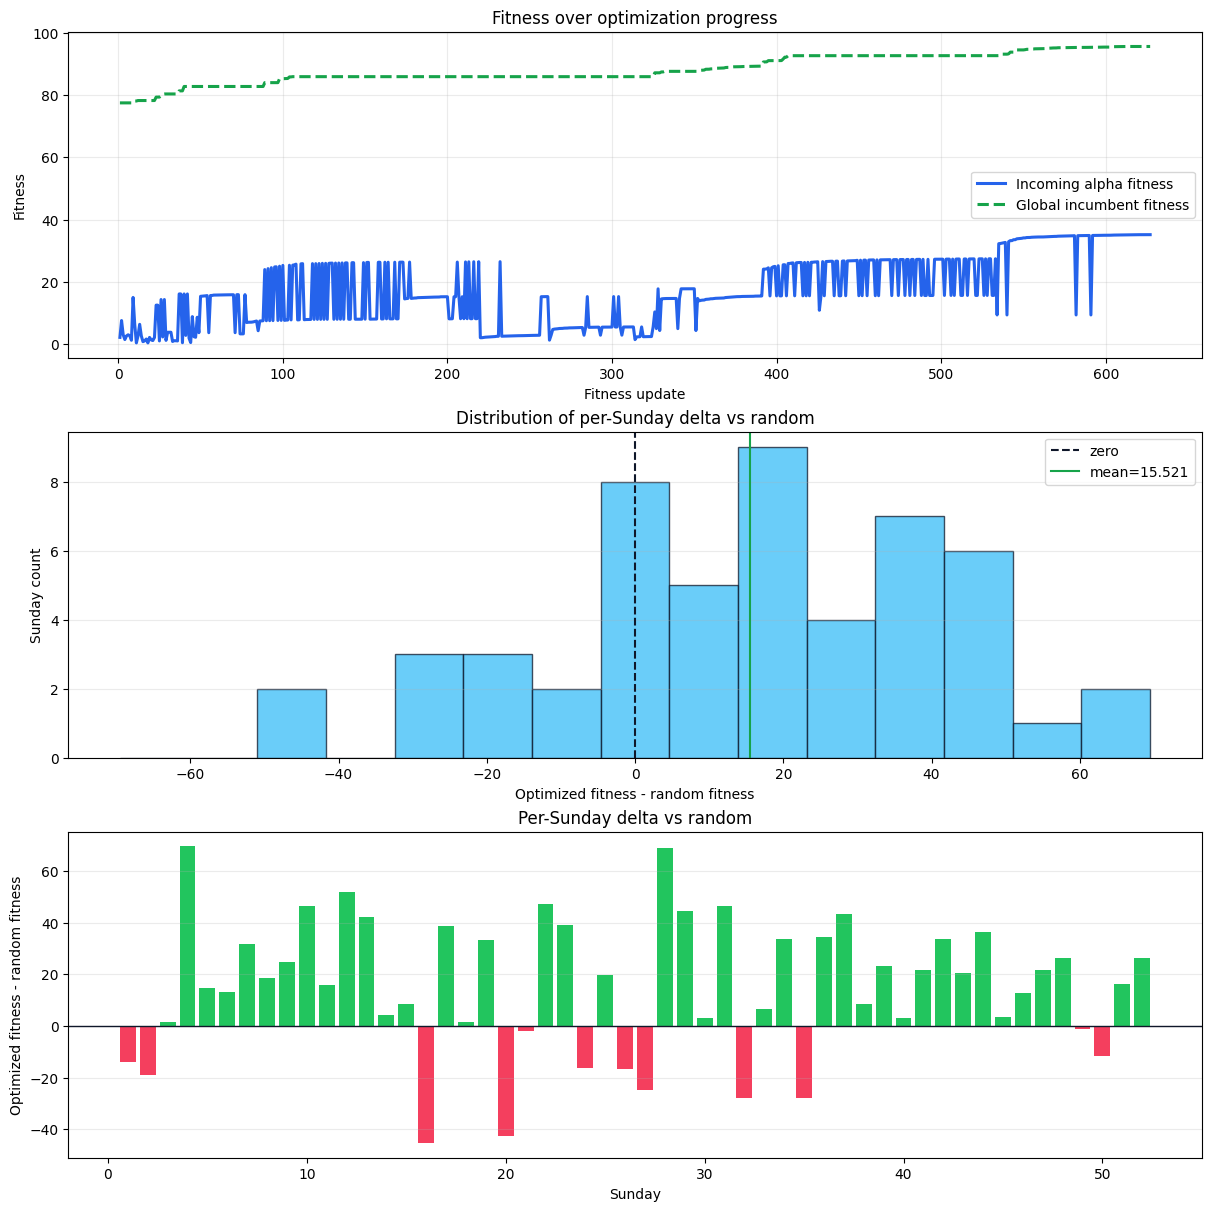

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LOCAL_TZ = datetime.now().astimezone().tzinfo

# Edit this to point at a completed job folder, not the results folder.
# Example on Windows:
# JOB_FOLDER = Path(r"D:\\Coding\\FAKS\\Mentor\\working-sundays\\.sunday-cache\\jetpans\\d9a3343b-3665-403e-8b11-3c55aa63d381")
JOB_FOLDER = r"C:\Users\stjep\Downloads\DemoFitness"


def load_stats_cache(job_folder):
    job_folder = Path(job_folder)
    cache_path = job_folder / "results" / "_stats_cache.json"
    if not cache_path.exists():
        raise FileNotFoundError(f"Stats cache not found: {cache_path}")

    payload = json.loads(cache_path.read_text(encoding="utf-8"))
    stats = payload.get("stats", payload)
    return payload, stats


def load_descriptor_run_info(job_folder):
    descriptor_path = Path(job_folder) / "descriptor.job"
    if not descriptor_path.exists():
        return {}

    descriptor = json.loads(descriptor_path.read_text(encoding="utf-8"))
    return descriptor.get("run_info") or {}


def parse_timestamp(value):
    if not value:
        return None
    if isinstance(value, (int, float)):
        return datetime.fromtimestamp(value, tz=LOCAL_TZ)
    try:
        parsed = datetime.fromisoformat(str(value))
    except ValueError:
        return None
    if parsed.tzinfo is None:
        return parsed.replace(tzinfo=LOCAL_TZ)
    return parsed.astimezone(LOCAL_TZ)


def file_timestamp(path, stat_name):
    path = Path(path)
    if not path.exists():
        return None
    value = getattr(path.stat(), stat_name, None)
    if value is None:
        return None
    return datetime.fromtimestamp(value, tz=LOCAL_TZ)


def seconds_between(start, finish):
    if not start or not finish:
        return None
    return max(0.0, (finish - start).total_seconds())


def estimate_execution_timing(job_folder):
    job_folder = Path(job_folder)
    run_info = load_descriptor_run_info(job_folder)
    solution_path = job_folder / "results" / "solution.json"

    started_at = parse_timestamp(run_info.get("started_at"))
    finished_at = parse_timestamp(run_info.get("finished_at"))
    java_started_at = parse_timestamp(run_info.get("java_started_at"))
    java_finished_at = parse_timestamp(run_info.get("java_finished_at"))

    rows = []
    if started_at or finished_at or run_info.get("duration_seconds") is not None:
        rows.append(
            {
                "metric": "backend run",
                "started_at": started_at,
                "finished_at": finished_at,
                "duration_seconds": run_info.get("duration_seconds") or seconds_between(started_at, finished_at),
                "source": "descriptor.job run_info",
                "reliability": "persisted for new runs",
            }
        )

    if java_started_at or java_finished_at or run_info.get("java_duration_seconds") is not None:
        rows.append(
            {
                "metric": "java process",
                "started_at": java_started_at,
                "finished_at": java_finished_at,
                "duration_seconds": run_info.get("java_duration_seconds") or seconds_between(java_started_at, java_finished_at),
                "source": "descriptor.job run_info",
                "reliability": "persisted for new runs",
            }
        )

    fallback_solution_finish = file_timestamp(solution_path, "st_mtime")
    if java_started_at and fallback_solution_finish and not java_finished_at:
        rows.append(
            {
                "metric": "java process estimate",
                "started_at": java_started_at,
                "finished_at": fallback_solution_finish,
                "duration_seconds": seconds_between(java_started_at, fallback_solution_finish),
                "source": "descriptor.job java_started_at -> results/solution.json mtime",
                "reliability": "best effort when java_finished_at is unavailable",
            }
        )

    return pd.DataFrame(rows)


def parse_fitness_history(job_folder):
    job_folder = Path(job_folder)
    history_path = job_folder / "results" / "fitness_history.csv"
    columns = [
        "step",
        "iteration",
        "fitness",
        "global_fitness",
        "best_global_fitness",
        "incoming_alpha_fitness",
        "elapsed_ms",
        "timestamp_ms",
    ]
    if not history_path.exists():
        return pd.DataFrame(columns=columns)

    df = pd.read_csv(history_path)
    required_columns = {"global_fitness", "best_global_fitness"}
    if df.empty or not required_columns.issubset(df.columns):
        return pd.DataFrame(columns=columns)

    df = df.reset_index(drop=True)
    df["step"] = df.index + 1
    df["fitness"] = df["global_fitness"]
    return df[[col for col in columns if col in df.columns]]


def stats_to_sunday_frame(stats):
    rows = []
    for entry in stats.get("per_sunday", []):
        random_value = float(entry.get("random", 0.0))
        optimized_value = float(entry.get("optimized", 0.0))
        delta = float(entry.get("delta", optimized_value - random_value))
        delta_pct = None if random_value == 0 else delta / abs(random_value) * 100.0
        rows.append(
            {
                "sunday": int(entry.get("sunday", len(rows))),
                "random": random_value,
                "optimized": optimized_value,
                "delta": delta,
                "delta_pct": delta_pct,
            }
        )

    df = pd.DataFrame(rows)
    if not df.empty:
        df["sunday_label"] = df["sunday"] + 1
    return df


def plot_fitness_history(fitness_df, use_iteration=False, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    if fitness_df.empty:
        ax.text(0.5, 0.5, "No fitness history found in fitness_history.csv", ha="center", va="center")
        ax.set_axis_off()
        return ax

    required_columns = {"global_fitness", "best_global_fitness"}
    if not required_columns.issubset(fitness_df.columns):
        ax.text(0.5, 0.5, "No fitness history found in fitness_history.csv", ha="center", va="center")
        ax.set_axis_off()
        return ax

    x_col = "iteration" if use_iteration and fitness_df["iteration"].notna().any() else "step"
    incoming_col = "global_fitness"
    incumbent_col = "best_global_fitness"

    ax.plot(
        fitness_df[x_col],
        fitness_df[incoming_col],
        color="#2563eb",
        linewidth=2.2,
        label="After incoming update fitness",
    )
    ax.plot(
        fitness_df[x_col],
        fitness_df[incumbent_col],
        color="#16a34a",
        linestyle="--",
        linewidth=2.2,
        label="Global incumbent fitness",
    )
    ax.set_title("Fitness over optimization progress")
    ax.set_xlabel("Iteration" if x_col == "iteration" else "Fitness update")
    ax.set_ylabel("Fitness")
    ax.legend()
    ax.grid(True, alpha=0.25)
    return ax


def plot_delta_distribution(sunday_df, bins=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    if sunday_df.empty:
        ax.text(0.5, 0.5, "No Sunday deltas available", ha="center", va="center")
        ax.set_axis_off()
        return ax

    deltas = sunday_df["delta"].to_numpy(dtype=float)
    max_abs = max(1.0, float(np.max(np.abs(deltas))))
    if bins is None:
        bin_count = min(17, max(7, int(np.ceil(np.sqrt(len(deltas)) * 2))))
        if bin_count % 2 == 0:
            bin_count += 1
        bins = np.linspace(-max_abs, max_abs, bin_count + 1)

    ax.hist(deltas, bins=bins, color="#38bdf8", edgecolor="#0f172a", alpha=0.75)
    ax.axvline(0, color="#0f172a", linestyle="--", linewidth=1.5, label="zero")
    ax.axvline(deltas.mean(), color="#16a34a", linestyle="-", linewidth=1.5, label=f"mean={deltas.mean():.3f}")
    ax.set_title("Distribution of per-Sunday delta vs random")
    ax.set_xlabel("Optimized fitness - random fitness")
    ax.set_ylabel("Sunday count")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.25)
    return ax


def plot_delta_by_sunday(sunday_df, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))

    if sunday_df.empty:
        ax.text(0.5, 0.5, "No Sunday deltas available", ha="center", va="center")
        ax.set_axis_off()
        return ax

    colors = np.where(sunday_df["delta"] >= 0, "#22c55e", "#f43f5e")
    ax.bar(sunday_df["sunday_label"], sunday_df["delta"], color=colors)
    ax.axhline(0, color="#0f172a", linewidth=1)
    ax.set_title("Per-Sunday delta vs random")
    ax.set_xlabel("Sunday")
    ax.set_ylabel("Optimized fitness - random fitness")
    ax.grid(True, axis="y", alpha=0.25)
    return ax


if JOB_FOLDER is None:
    print("Set JOB_FOLDER to a completed job directory, then run this cell.")
else:
    cache_payload, stats = load_stats_cache(JOB_FOLDER)
    timing_df = estimate_execution_timing(JOB_FOLDER)
    fitness_df = parse_fitness_history(JOB_FOLDER)
    sunday_df = stats_to_sunday_frame(stats)

    print(f"Loaded stats from: {Path(JOB_FOLDER) / 'results' / '_stats_cache.json'}")
    print("Cache metadata:")
    print({k: v for k, v in cache_payload.items() if k != "stats"})
    print("Overall stats:")
    print(stats.get("overall", {}))

    print("Execution timing:")
    if timing_df.empty:
        print("No persisted timing or usable filesystem timestamp estimate found.")
    else:
        display(timing_df)

    display(sunday_df.head())
    display(fitness_df.head())

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)
    plot_fitness_history(fitness_df, ax=axes[0])
    plot_delta_distribution(sunday_df, ax=axes[1])
    plot_delta_by_sunday(sunday_df, ax=axes[2])
    plt.show()
